Get dataset

In [133]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor

batch_size = 64

train_set = CIFAR10(root='data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)

test_set = CIFAR10(root='data', train=False, download=True, transform=ToTensor())
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Check picture size

In [134]:
print(train_set[0][0].shape)
print(train_set[0][1])

torch.Size([3, 32, 32])
6


CNN (VGG structure)

In [135]:
from torch.nn import Sequential, Conv2d, MaxPool2d, Linear, ReLU, Flatten, Softmax

input_dim = 3
output_dim = 10

model = Sequential(
    Conv2d(input_dim, out_channels=input_dim * 4, kernel_size=3, padding=1),  # (12, 32, 32)
    ReLU(),
    MaxPool2d(kernel_size=2),
    Conv2d(input_dim * 4, out_channels=input_dim * 16, kernel_size=3, padding=1),  # (48, 16, 16)
    ReLU(),
    MaxPool2d(kernel_size=2),
    Conv2d(input_dim * 16, out_channels=input_dim * 64, kernel_size=3, padding=1),  # (192, 8, 8)
    ReLU(),
    MaxPool2d(kernel_size=2),  # (192, 4, 4)
    Flatten(),
    Linear(input_dim * 64 * 4 * 4, input_dim * 32),
    ReLU(),
    Linear(input_dim * 32, output_dim),
)

Get GPU

In [136]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)
print(device)

cuda


Training

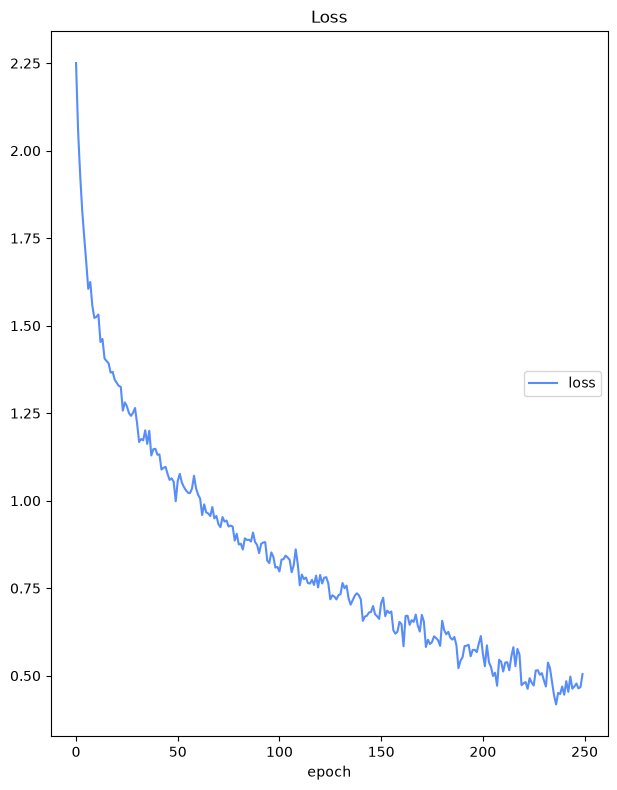

Loss
	loss             	 (min:    0.418, max:    2.250, cur:    0.504)


In [137]:
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from livelossplot import PlotLosses

plotlosses = PlotLosses()

learning_rate = 0.0005
optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = CrossEntropyLoss()

epoch = 0
epoch_loss = 0
print_epoch = 50
round = 16

for i in range(round):
    for data in train_loader:
        input, labels = data
        optimizer.zero_grad()
        loss = criterion(model(input.to(device)), labels.to(device))
        loss.backward()
        optimizer.step()
        epoch += 1
        epoch_loss += loss.item()

        if epoch % print_epoch == 0:
            plotlosses.update({'loss': epoch_loss / print_epoch})
            plotlosses.send()
            epoch_loss = 0


Result Check

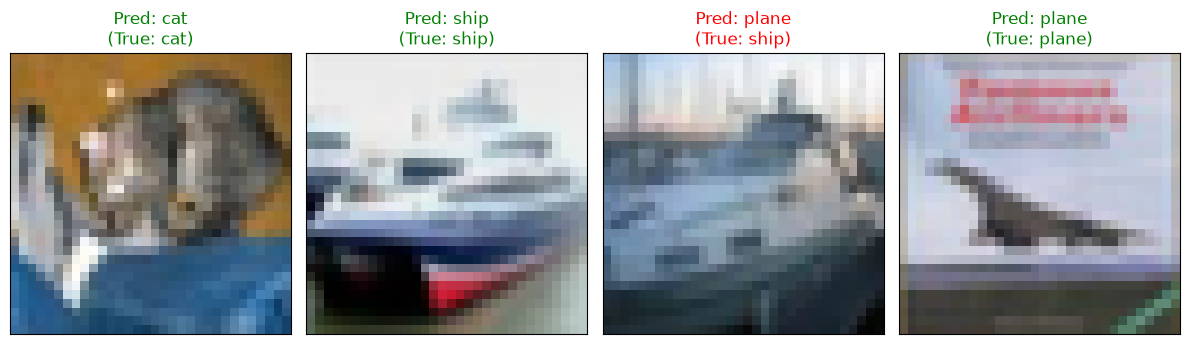

In [138]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

data_iter = iter(test_loader)
images, labels = next(data_iter)

images_gpu = images.to(device)
with torch.no_grad():
    outputs = model(images_gpu)
    _, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 4))
batch_size_to_show = min(len(images), 4)

for idx in range(batch_size_to_show):
    ax = fig.add_subplot(1, batch_size_to_show, idx + 1, xticks=[], yticks=[])
    img = images[idx].numpy().transpose((1, 2, 0))

    img = np.clip(img, 0, 1)

    ax.imshow(img)

    pred_title = classes[predicted[idx].item()]
    true_title = classes[labels[idx].item()]

    color = "green" if pred_title == true_title else "red"
    ax.set_title(f"Pred: {pred_title}\n(True: {true_title})", color=color, fontsize=12)

plt.tight_layout()
plt.show()